<a href="https://colab.research.google.com/github/AkankshaB123/ML/blob/main/Profit_Prediction_50_StartupsMultiple_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# =============================================================================
#  Multiple Linear Regression
# =============================================================================

# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import seaborn as sns

In [3]:
# =============================================================================
# # Importing the dataset
# =============================================================================

dataset = pd.read_csv('/content/sample_data/50_Startups.csv')
dataset.head(4)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99


# EDA

In [4]:
print('There are ',dataset.shape[0],'rows and ',dataset.shape[1],'columns in the dataset.')

There are  50 rows and  5 columns in the dataset.


In [7]:
c = dataset.select_dtypes(include=np.number).corr()
c

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


In [15]:
for col in dataset.columns:
    print(f"{col}: {dataset[col].nunique()} unique values")

R&D Spend: 49 unique values
Administration: 50 unique values
Marketing Spend: 48 unique values
State: 3 unique values
Profit: 50 unique values


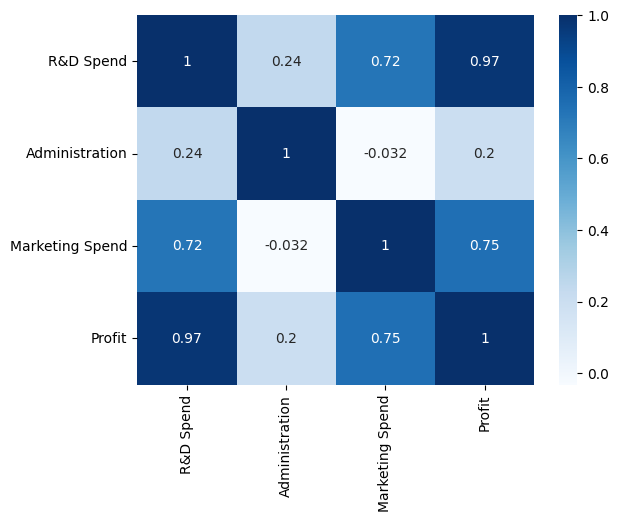

In [9]:
sns.heatmap(c,annot=True,cmap='Blues')
plt.show()

## State-wise Outlier Detection

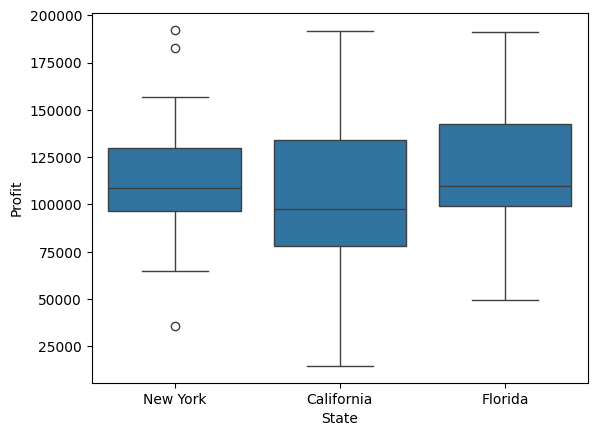

In [10]:
sns.boxplot(x = 'State', y = 'Profit', data = dataset)
plt.show()

1. All outliers presented are in New York.
2. The startups located in California we can see the maximum profits and maximum loss.

/tmp/ipykernel_1321/1656791243.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['Profit'],bins=5,kde=True)


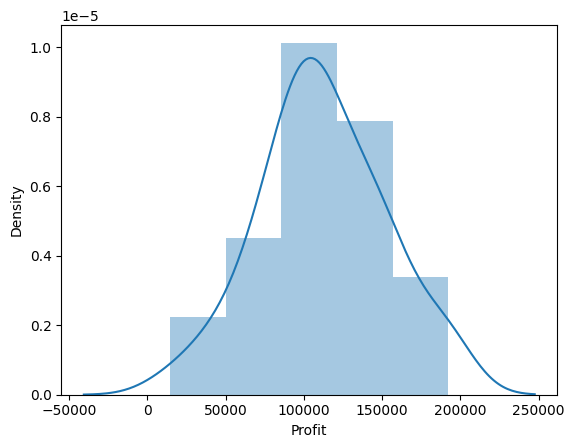

In [11]:
sns.distplot(dataset['Profit'],bins=5,kde=True)
plt.show()

Inference: The average profit (which is 100k) is the most frequent i.e. this should be in the category of distribution plot.

# 01. Scatterplots (Numeric Features vs Profit)

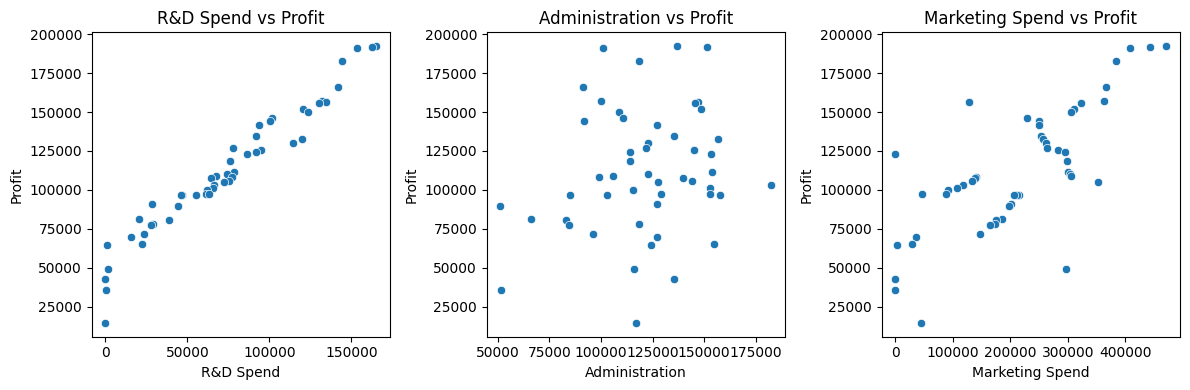

In [18]:
features = ['R&D Spend', 'Administration', 'Marketing Spend']
target = 'Profit'

plt.figure(figsize=(12,4))

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=dataset[col], y=dataset[target])
    plt.title(f"{col} vs {target}")

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

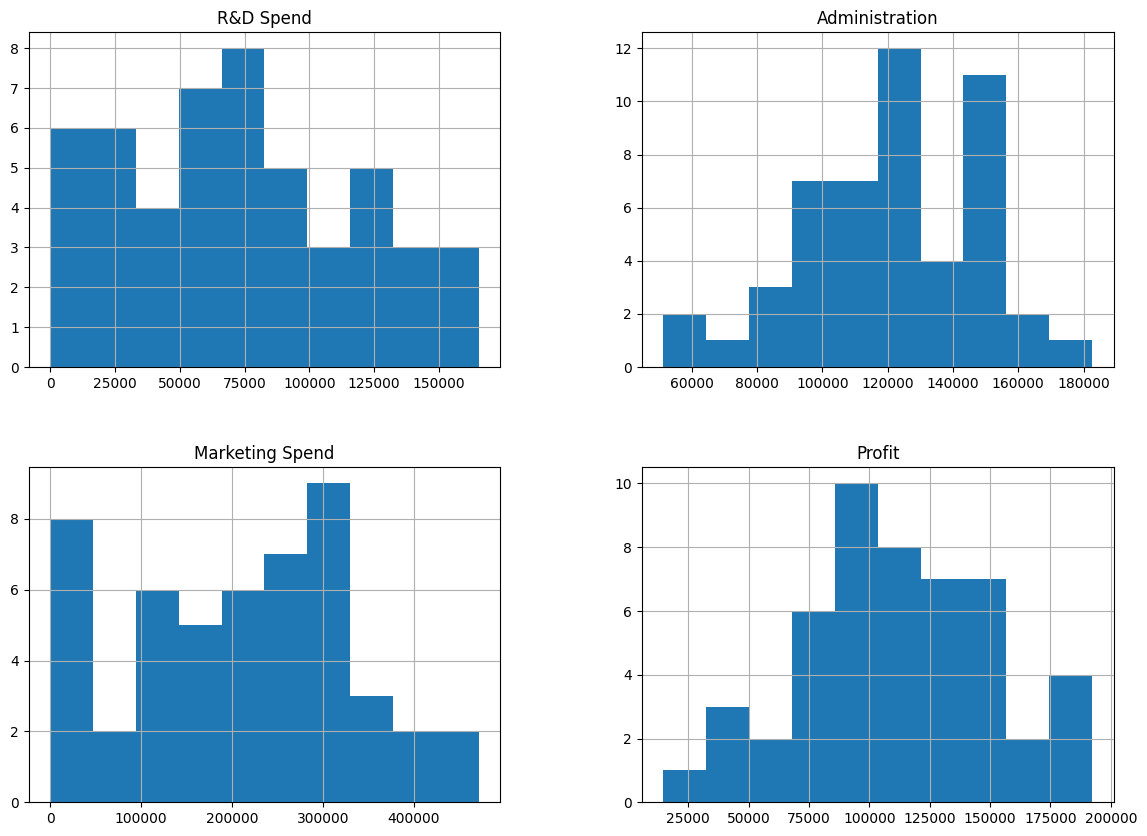

In [20]:
dataset.hist(figsize=(14,10))
plt.show

# 02. Data Description (IMPORTANT)

In [23]:
dataset.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


# 03. Creating the Independendent and Dependent Data Sets

In [24]:
X = dataset.iloc[:, :-1].values #Feature Data
y = dataset.iloc[:, 4].values # Dependent Data

X_data=pd.DataFrame(X)

In [69]:
X_data.head(4)

,0,1,2,3
0,165349.2,136897.8,471784.1,2
1,162597.7,151377.59,443898.53,0
2,153441.51,101145.55,407934.54,1
3,144372.41,118671.85,383199.62,2


In [33]:
# =============================================================================
#  label Encoder vs One-Hot Encoding categorical data
# =============================================================================

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer # Import ColumnTransformer

#Label Encoder : Encode labels with value between 0 and n_classes-1.
# Ensure the 'State' column is explicitly treated as string before encoding, to avoid potential issues if X is object dtype
labelencoder = LabelEncoder()
X[:, 3] = labelencoder.fit_transform(X[:, 3].astype(str))
X1 = pd.DataFrame(X)


#One-Hot  Encoder : Encode categorical integer features as a one-hot numeric array.
# Use ColumnTransformer for one-hot encoding specific columns
ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(), [3])], # Apply OneHotEncoder to column 3
    remainder='passthrough' # Keep other columns as they are
)
# Transform X, convert sparse output to a dense NumPy array, and then cast to float
X = ct.fit_transform(X).toarray().astype(float)
X2=pd.DataFrame(X)

# The original code had X = X[:, 1:] to drop one dummy variable.
# With ColumnTransformer, the one-hot encoded columns are at the beginning.
# So, X = X[:, 1:] correctly drops the first dummy variable to avoid multicollinearity.
X = X[:, 1:]

In [26]:
# =============================================================================
# #Missing Value
dataset.isnull().sum()
# =============================================================================

,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


# 04. Splitting the dataset into the Training set and Test set

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [29]:
# Fitting Multiple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

In [30]:
# Predicting the Test set results
y_pred = regressor.predict(X_test)
y_pred_data=pd.DataFrame(y_pred)

regressor.score(X_train,y_train)

regressor.score(X_test,y_test)

0.9347068473282987

In [35]:
# =============================================================================
# #Model Statistics
# =============================================================================

#Adding Intercept term to the model and ensuring float type
X_train = sm.add_constant(X_train).astype(float)
X_test = sm.add_constant(X_test).astype(float)

#Converting into Dataframe
X_train_d=pd.DataFrame(X_train)


#Printing the Model Statistics
# To get the summary for the trained model, we should fit sm.OLS with the training data (y_train, X_train)
model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     129.7
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           3.91e-21
Time:                        12:02:53   Log-Likelihood:                -421.10
No. Observations:                  40   AIC:                             854.2
Df Residuals:                      34   BIC:                             864.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.255e+04   8358.538      5.091      0.000    2.56e+04    5.95e+04
x1          -959.2842   4038.108     -0.238      0.814   -9165.706    7247.138
x2           699.3691   3661.563      0.191      0.850   -6741.822    8140.560
x3             0.7735      0.055     14.025      0.000       0.661       0.886
x4             0.0329      0.066      0.495      0.624      -0.102       0.168
x5             0.0366      0.019      1.884      0.068      -0.003       0.076
==============================================================================
Omnibus:                       15.823   Durbin-Watson:                   2.468
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               23.231
Skew:                          -1.094   Prob(JB):                     9.03e-06
Kurtosis:                       6.025   Cond. No.                     1.49e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.49e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [41]:
from sklearn.metrics import mean_squared_error, r2_score

#Evaluation

print("MSE:",mean_squared_error(y_test,y_pred))
print("R2 Score:",r2_score(y_test,y_pred))

MSE: 83502864.03250548
R2 Score: 0.9347068473282987


In [40]:
#Checking the VIF Value

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["VIF Factor"] =[variance_inflation_factor(X_train_d.values, j) for j in range(X_train_d.shape[1])]
vif["features"] = X_train_d.columns
vif.round(1)

,VIF Factor,features
0,29.1,0
1,1.3,1
2,1.3,2
3,2.7,3
4,1.2,4
5,2.4,5


In [39]:
#Storing Coefficients in DataFrame along with coloumn names
coefficients = pd.concat([pd.DataFrame(X_train_d.columns),pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)

# 01. Multiple Linear Regression (Using sklearn)

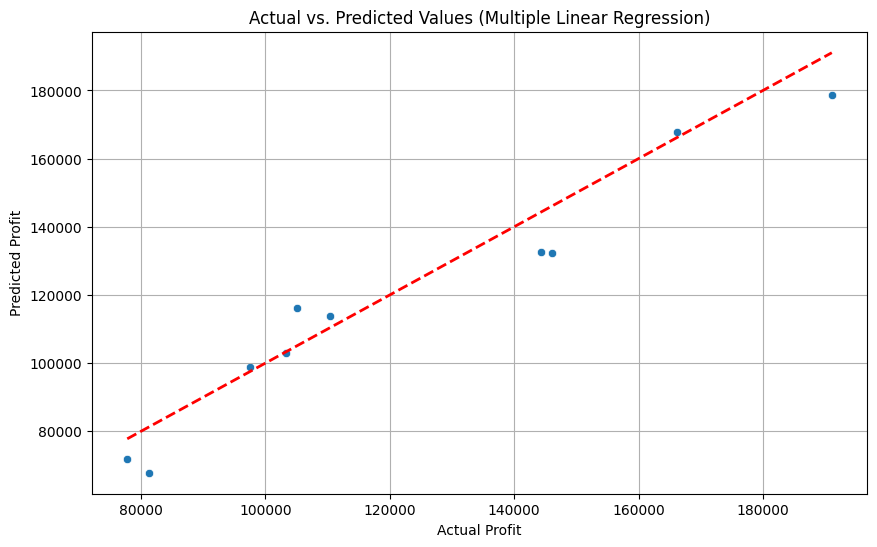

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted Values (Multiple Linear Regression)')
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.grid(True)
plt.show()

# 02. Model 2: Decision Tree

In [47]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=5, random_state=0)
dt.fit(X_train, y_train)

print('Training score:',dt.score(X_train, y_train))
print('Test score:',dt.score(X_test, y_test))

Training score: 0.999176799672176
Test score: 0.9755665937853926


In [52]:
feature_names = ['const', 'State_Florida', 'State_New York', 'R&D Spend', 'Administration', 'Marketing Spend']
feature_names

['const',
 'State_Florida',
 'State_New York',
 'R&D Spend',
 'Administration',
 'Marketing Spend']

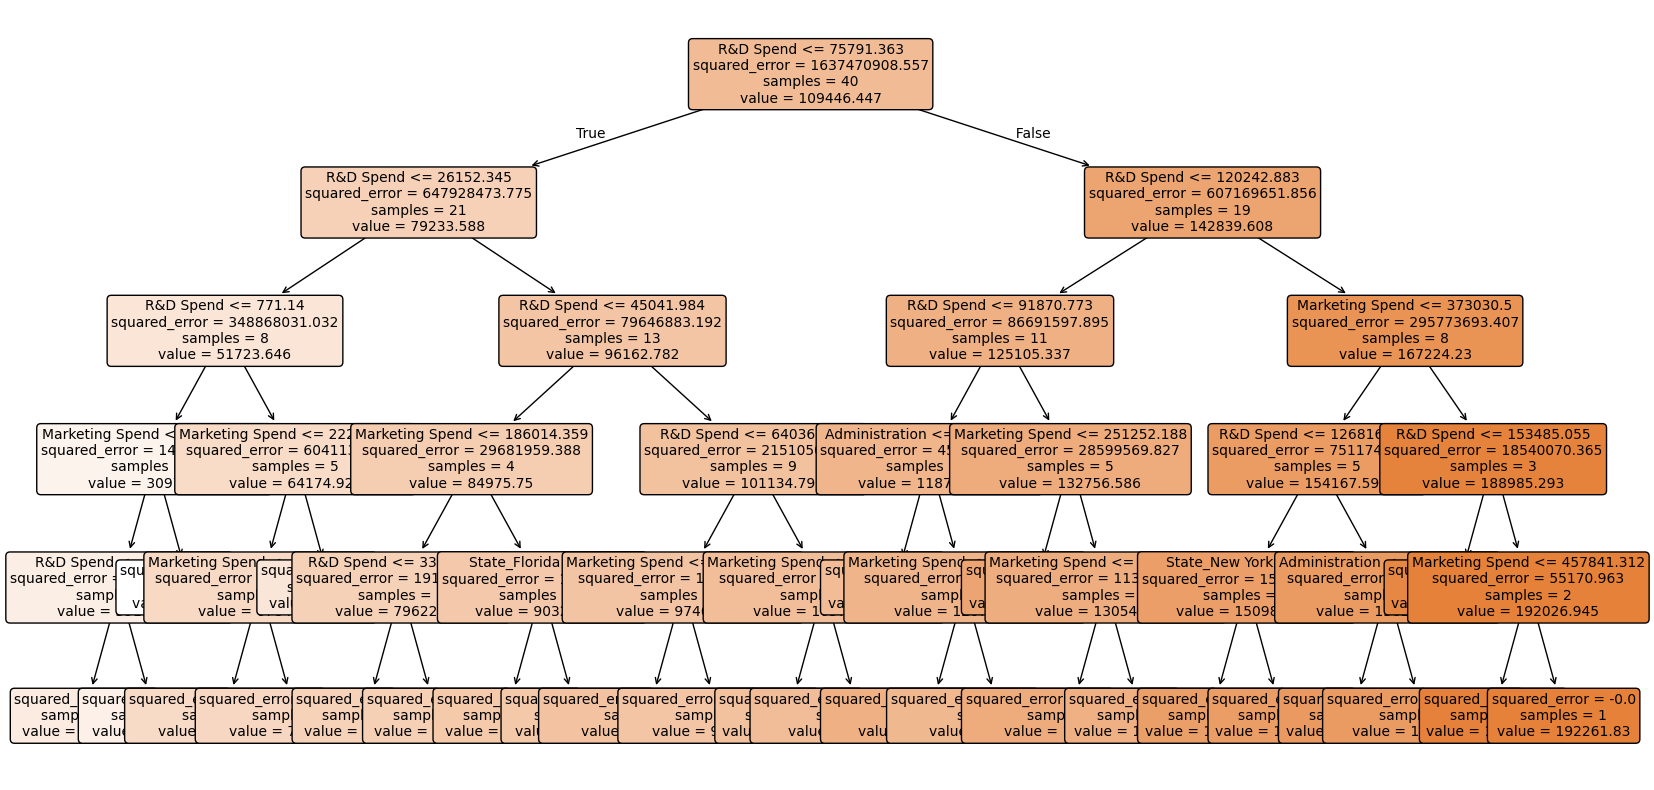

In [53]:
# plot tree
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=feature_names, filled=True, rounded=True, fontsize=10);

# Model 03. MULTIPLE LINEAR REGRESSION WITHOUT SKLEARN

In [60]:
X = dataset[["R&D Spend","Administration","Marketing Spend"]].values
y = dataset["Profit"].values

In [61]:
#Add Bias Column
ones = np.ones((X.shape[0],1))
X = np.hstack((ones, X))

In [62]:
beta = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)

print("Coefficients:", beta)

Coefficients: [ 5.01221930e+04  8.05715050e-01 -2.68159687e-02  2.72280647e-02]


# Model 04. Gradient Descent Implementation

In [64]:
X = dataset["R&D Spend"].values
y = dataset["Profit"].values

In [65]:
# Normalize feature
X = (X - X.mean()) / X.std()

#Initialize Parameters

m = 0
b = 0

learning_rate = 0.001
epochs = 1000
n = len(X)

In [66]:
#Gradient Descent Loop

for i in range(epochs):

    y_pred = m*X + b

    dm = (-2/n) * np.sum(X*(y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    m = m - learning_rate*dm
    b = b - learning_rate*db

In [67]:
#Final Parameters

print("Slope:", m)
print("Intercept:", b)

Slope: 33576.606728231935
Intercept: 96883.70557845943


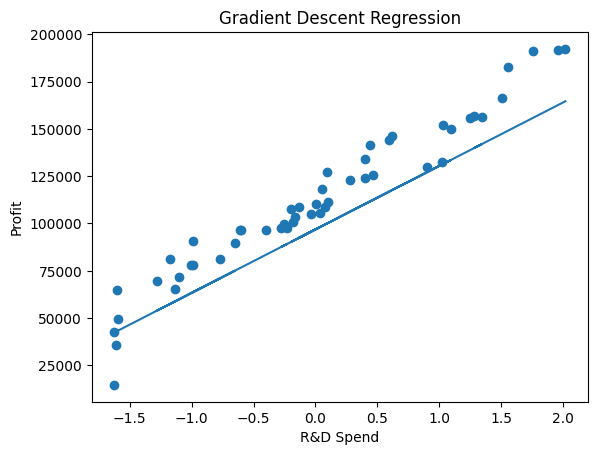

In [68]:
plt.scatter(X,y)
plt.plot(X, m*X + b)
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("Gradient Descent Regression")
plt.show()